## **Atelier Seaborn**

In [16]:
%pip install seaborn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: C:\Users\HP 450 G8\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [17]:
# Import des bibliothèques nécessaires pour tout le notebook
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Thème Seaborn appliqué à l'ensemble du notebook
sns.set_theme(style="whitegrid")

print("Pandas version    :", pd.__version__)
print("NumPy version     :", np.__version__)
print("Matplotlib version:", plt.matplotlib.__version__)
print("Seaborn version   :", sns.__version__)

Pandas version    : 3.0.3
NumPy version     : 2.5.0
Matplotlib version: 3.11.1
Seaborn version   : 0.13.2


### Import et vérification du jeu de données

In [18]:
# Import du CSV fourni dans le DataFrame df
df = pd.read_csv("../data/mesures_capteurs.csv")
df.head()

,id_mesure,date_heure,id_capteur,batiment,temperature,humidite,pression,consommation,etat
0,M0413,2026-01-22 04:00:00,C005,B002,25.46,58.06,1008.95,287.28,OK
1,M0290,2026-01-17 01:00:00,C002,B001,24.00,79.73,993.39,116.20,OK
2,M0077,2026-01-08 04:00:00,C005,B002,25.82,54.47,1010.32,288.50,OK
3,M0079,2026-01-08 06:00:00,C007,B003,28.23,69.39,1019.62,136.65,OK
4,M0183,2026-01-12 14:00:00,C003,B001,20.58,53.80,1016.58,182.62,OK


In [19]:
# Vérification du contenu du DataFrame
print("Dimensions :", df.shape)
df.info()

Dimensions : (605, 9)
<class 'pandas.DataFrame'>
RangeIndex: 605 entries, 0 to 604
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id_mesure     605 non-null    str    
 1   date_heure    605 non-null    str    
 2   id_capteur    605 non-null    str    
 3   batiment      605 non-null    str    
 4   temperature   599 non-null    float64
 5   humidite      600 non-null    float64
 6   pression      600 non-null    float64
 7   consommation  600 non-null    float64
 8   etat          601 non-null    str    
dtypes: float64(4), str(5)
memory usage: 63.0 KB


In [20]:
# Statistiques descriptives des colonnes numériques
df.describe()

,temperature,humidite,pression,consommation
count,599.000000,600.00000,600.000000,600.000000
mean,24.878314,64.92620,1012.221900,208.675417
std,4.059576,10.76905,10.599042,72.243567
min,-18.500000,28.52000,850.000000,18.120000
25%,22.570000,58.17250,1006.790000,160.177500
50%,24.860000,65.37500,1012.855000,206.150000
75%,27.275000,71.61500,1017.827500,254.127500
max,58.700000,145.00000,1038.430000,875.000000


Le jeu de données contient 605 mesures réparties sur 4 bâtiments (B001 à B004), avec quelques valeurs manquantes (colonnes `temperature`, `humidite`, `pression`, `consommation`, `etat`) déjà identifiées lors de l'atelier Pandas. Ces valeurs manquantes sont ignorées automatiquement par Seaborn dans les graphiques qui suivent, ce qui n'empêche pas de mener l'analyse exploratoire.

## Partie 1 – Distribution d'une variable avec `histplot()`

1) Distribution des températures

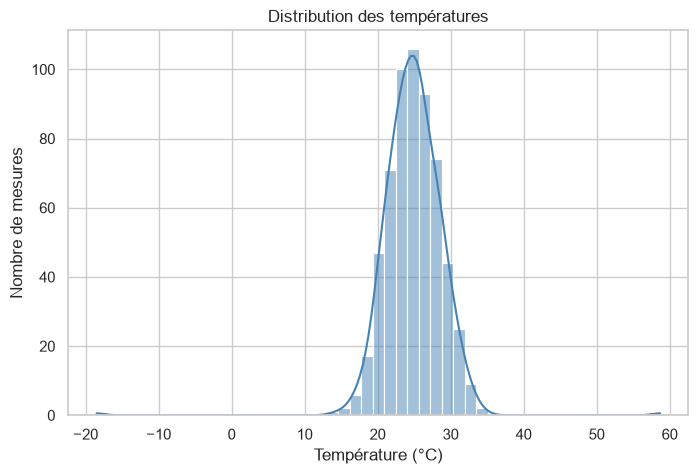

In [21]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="temperature", kde=True, color="steelblue")
plt.title("Distribution des températures")
plt.xlabel("Température (°C)")
plt.ylabel("Nombre de mesures")
plt.show()

In [22]:
print("Moyenne   :", round(df["temperature"].mean(), 2))
print("Médiane   :", round(df["temperature"].median(), 2))
print("Ecart-type:", round(df["temperature"].std(), 2))
print("Min / Max :", df["temperature"].min(), "/", df["temperature"].max())

Moyenne   : 24.88
Médiane   : 24.86
Ecart-type: 4.06
Min / Max : -18.5 / 58.7


2) **Concentration** : les températures sont concentrées autour de 25°C (moyenne 24,9°C, médiane 24,9°C), ce qui correspond à une température ambiante intérieure classique pour des bâtiments équipés de capteurs.

3) **Symétrie** : la distribution est globalement symétrique autour de sa valeur centrale — le corps de l'histogramme suit une forme proche d'une cloche. Elle est cependant légèrement étalée vers les deux extrémités à cause des valeurs aberrantes.

4) **Valeurs extrêmes** : oui, on observe des valeurs extrêmes très éloignées du reste de la distribution (température minimale de -18,5°C et maximale de 58,7°C), physiquement peu plausibles pour des capteurs intérieurs — probablement des erreurs de capteur ou de transmission.

5) Modification du nombre de classes (bins)

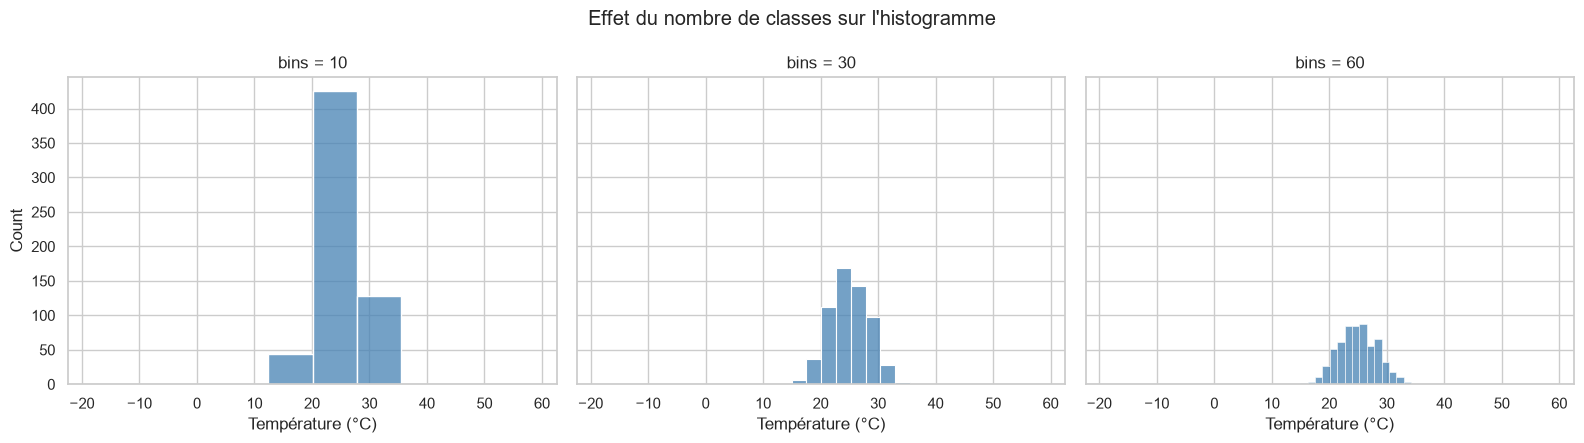

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), sharey=True)

for ax, nb_bins in zip(axes, [10, 30, 60]):
    sns.histplot(data=df, x="temperature", bins=nb_bins, color="steelblue", ax=ax)
    ax.set_title(f"bins = {nb_bins}")
    ax.set_xlabel("Température (°C)")

fig.suptitle("Effet du nombre de classes sur l'histogramme")
plt.tight_layout()
plt.show()

Plus le nombre de classes augmente, plus le détail de la distribution apparaît (on distingue mieux les valeurs extrêmes isolées), mais la lecture générale de la tendance devient aussi plus bruitée. À l'inverse, un faible nombre de classes lisse la distribution au risque de masquer certains détails.

6) Distribution des températures par bâtiment

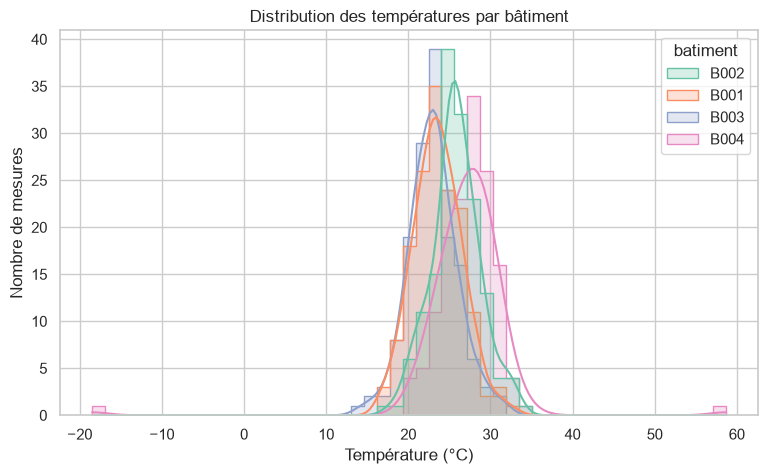

In [24]:
plt.figure(figsize=(9, 5))
sns.histplot(data=df, x="temperature", hue="batiment", kde=True, element="step", palette="Set2")
plt.title("Distribution des températures par bâtiment")
plt.xlabel("Température (°C)")
plt.ylabel("Nombre de mesures")
plt.show()

Le bâtiment B004 se distingue nettement des trois autres : sa distribution est plus étalée et c'est lui qui porte les valeurs extrêmes (-18,5°C et 58,7°C), alors que B001, B002 et B003 restent regroupés dans une plage plus resserrée autour de 24-26°C.

## Partie 2 – Distribution d'une variable avec `kdeplot()`

1) Distribution des températures

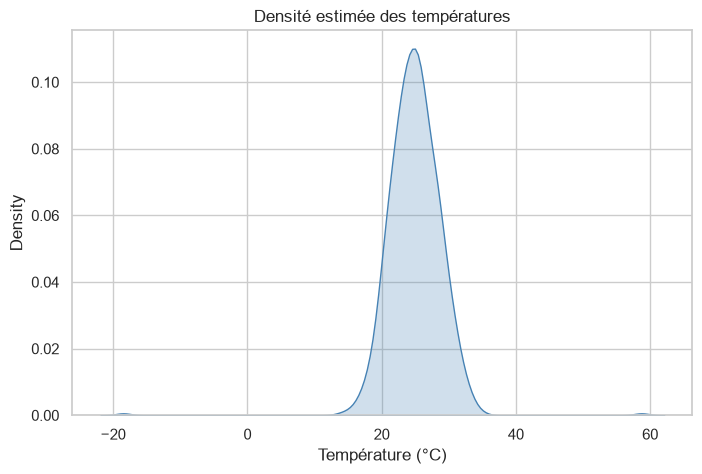

In [25]:
plt.figure(figsize=(8, 5))
sns.kdeplot(data=df, x="temperature", fill=True, color="steelblue")
plt.title("Densité estimée des températures")
plt.xlabel("Température (°C)")
plt.show()

La courbe de densité confirme la lecture faite avec l'histogramme : un pic principal autour de 25°C et une distribution globalement symétrique, avec des queues fines qui traduisent la présence des valeurs extrêmes.

2) Distribution des températures par bâtiment

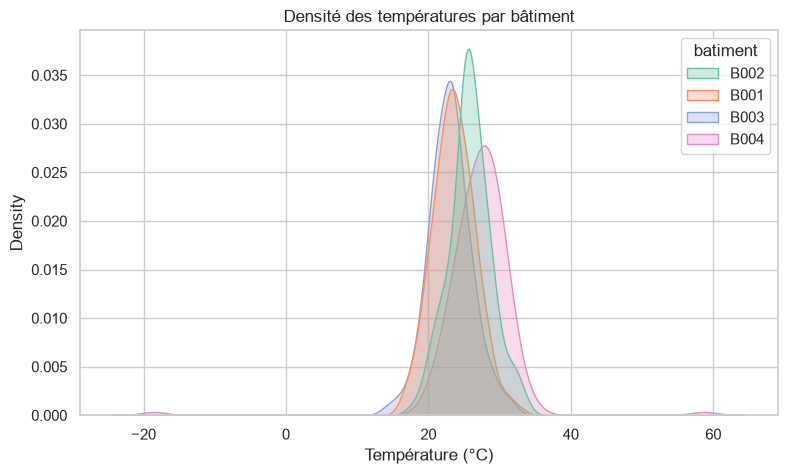

In [26]:
plt.figure(figsize=(9, 5))
sns.kdeplot(data=df, x="temperature", hue="batiment", fill=True, alpha=0.3, palette="Set2")
plt.title("Densité des températures par bâtiment")
plt.xlabel("Température (°C)")
plt.show()

Le `kdeplot()` rend encore plus visible ce que l'histogramme suggérait : les densités de B001, B002 et B003 sont proches et bien superposées, tandis que celle de B004 est plus aplatie et étalée sur une plage beaucoup plus large, signe d'une variabilité plus forte dans ce bâtiment.

## Partie 3 – Distribution d'une variable avec `boxplot()`

1) Distribution des températures

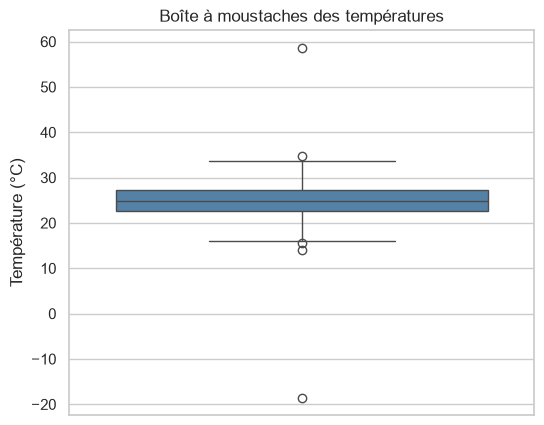

In [27]:
plt.figure(figsize=(6, 5))
sns.boxplot(data=df, y="temperature", color="steelblue")
plt.title("Boîte à moustaches des températures")
plt.ylabel("Température (°C)")
plt.show()

2) Distribution des températures par bâtiment

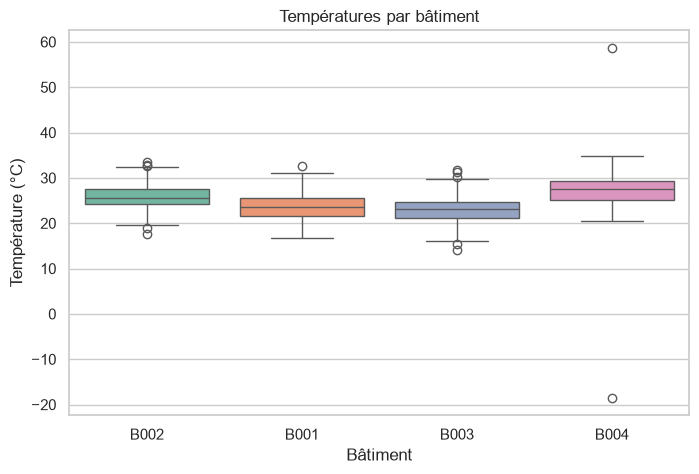

In [28]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="batiment", y="temperature", hue="batiment", palette="Set2", legend=False)
plt.title("Températures par bâtiment")
plt.xlabel("Bâtiment")
plt.ylabel("Température (°C)")
plt.show()

3) Statistiques par bâtiment (médiane, dispersion, valeurs extrêmes)

In [29]:
stats_batiment = df.groupby("batiment")["temperature"].agg(
    mediane="median", ecart_type="std", minimum="min", maximum="max"
).round(2)
stats_batiment

,mediane,ecart_type,minimum,maximum
batiment,,,,
B001,23.54,2.96,16.77,32.72
B002,25.67,2.95,17.67,33.60
B003,23.04,2.98,14.11,31.74
B004,27.53,5.37,-18.50,58.70


a) **Médiane** : elle varie peu d'un bâtiment à l'autre — autour de 23-24°C pour B001 et B003, un peu plus haute pour B002 (25,7°C), et nettement plus haute pour B004 (27,5°C).

b) **Dispersion** : B001, B002 et B003 ont un écart-type proche (environ 3°C), ce qui traduit des boîtes de taille comparable. B004 est nettement plus dispersé (écart-type d'environ 5,4°C), avec une boîte visuellement plus haute sur le graphique.

c) **Valeurs extrêmes** : des points isolés apparaissent au-delà des moustaches pour plusieurs bâtiments, mais c'est B004 qui concentre les points les plus éloignés, avec les valeurs -18,5°C et 58,7°C.

4) **Bâtiment le plus extrême** : B004 est clairement le bâtiment avec les valeurs les plus extrêmes et la dispersion la plus importante, ce qui en fait un candidat prioritaire pour une vérification du matériel de mesure.

## Partie 4 – Distribution d'une variable avec `violinplot()`

1) Distribution des températures

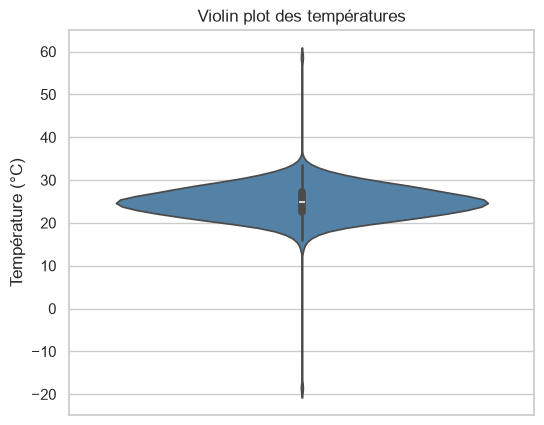

In [30]:
plt.figure(figsize=(6, 5))
sns.violinplot(data=df, y="temperature", color="steelblue")
plt.title("Violin plot des températures")
plt.ylabel("Température (°C)")
plt.show()

2) Distribution des températures par bâtiment

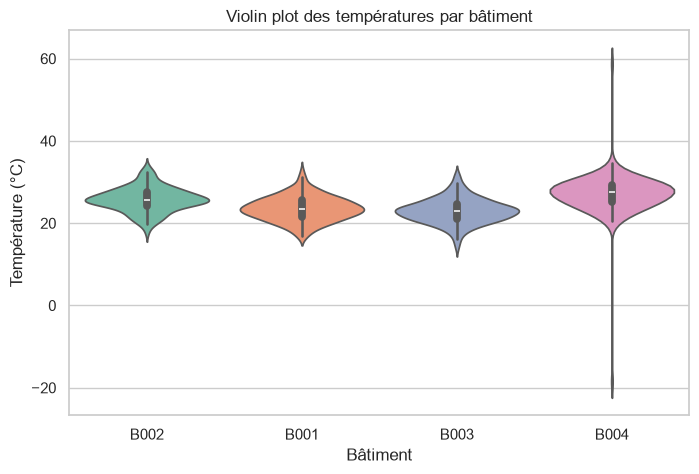

In [31]:
plt.figure(figsize=(8, 5))
sns.violinplot(data=df, x="batiment", y="temperature", hue="batiment", palette="Set2", legend=False)
plt.title("Violin plot des températures par bâtiment")
plt.xlabel("Bâtiment")
plt.ylabel("Température (°C)")
plt.show()

3) **Apport par rapport au boxplot** : le violin plot ajoute la forme de la densité de la distribution (largeur du violon) à ce que montre déjà le boxplot (médiane, quartiles, valeurs extrêmes). On voit par exemple que la distribution de B004 n'est pas juste plus dispersée : elle est aussi clairement bimodale/étalée, avec une masse de valeurs autour de 27-28°C et une traîne fine vers les extrêmes — une information invisible sur un simple boxplot.

## Partie 5 – Comptage des catégories avec `countplot()`

1) Nombre de mesures par état

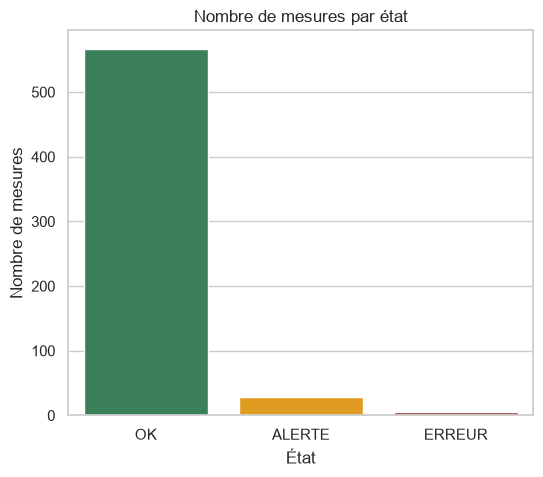

In [32]:
plt.figure(figsize=(6, 5))
sns.countplot(data=df, x="etat", hue="etat", order=["OK", "ALERTE", "ERREUR"],
              palette={"OK": "seagreen", "ALERTE": "orange", "ERREUR": "firebrick"}, legend=False)
plt.title("Nombre de mesures par état")
plt.xlabel("État")
plt.ylabel("Nombre de mesures")
plt.show()

2) Nombre de mesures par bâtiment

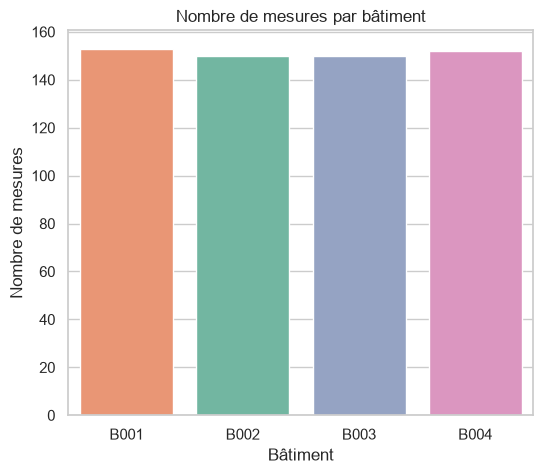

In [33]:
plt.figure(figsize=(6, 5))
sns.countplot(data=df, x="batiment", hue="batiment", order=sorted(df["batiment"].dropna().unique()),
              palette="Set2", legend=False)
plt.title("Nombre de mesures par bâtiment")
plt.xlabel("Bâtiment")
plt.ylabel("Nombre de mesures")
plt.show()

3) États des capteurs par bâtiment

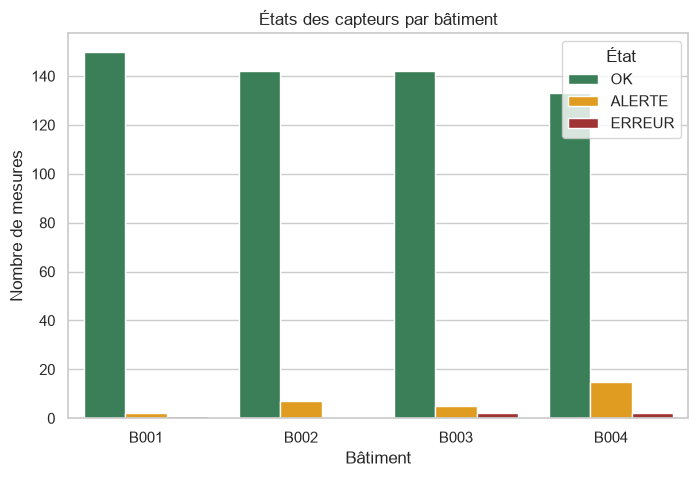

In [34]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="batiment", hue="etat",
              order=sorted(df["batiment"].dropna().unique()),
              hue_order=["OK", "ALERTE", "ERREUR"],
              palette={"OK": "seagreen", "ALERTE": "orange", "ERREUR": "firebrick"})
plt.title("États des capteurs par bâtiment")
plt.xlabel("Bâtiment")
plt.ylabel("Nombre de mesures")
plt.legend(title="État")
plt.show()

In [35]:
repartition_etat = df.groupby(["batiment", "etat"]).size().unstack(fill_value=0)
repartition_etat

etat,ALERTE,ERREUR,OK
batiment,,,
B001,2,1,150
B002,7,0,142
B003,5,2,142
B004,15,2,133


a) **Bâtiment le plus en OK** : B001 (150 mesures OK).

b) **Bâtiment le plus en ALERTE** : B004 (15 mesures en alerte), loin devant les autres bâtiments.

c) **Bâtiment le plus en ERREUR** : B003 et B004 sont à égalité (2 mesures en erreur chacun).

Ce constat confirme et complète les observations des parties précédentes : B004 n'est pas seulement le bâtiment aux températures les plus extrêmes, c'est aussi celui qui déclenche le plus d'alertes — un bon candidat à surveiller en priorité.

## Partie 6 – Relation entre deux variables avec `scatterplot()`

1) Relation entre température et consommation

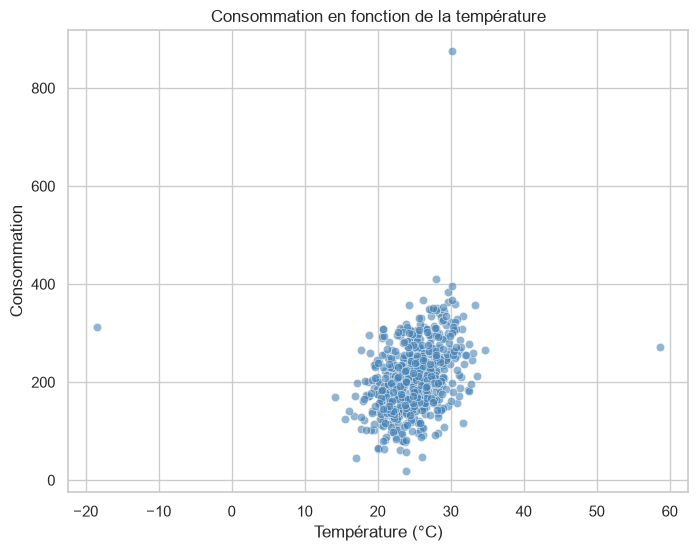

In [36]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x="temperature", y="consommation", color="steelblue", alpha=0.6)
plt.title("Consommation en fonction de la température")
plt.xlabel("Température (°C)")
plt.ylabel("Consommation")
plt.show()

On distingue une légère tendance : la consommation a tendance à augmenter avec la température, mais le nuage de points reste assez dispersé — la relation n'est pas très marquée.

2) Relation entre température et consommation par bâtiment

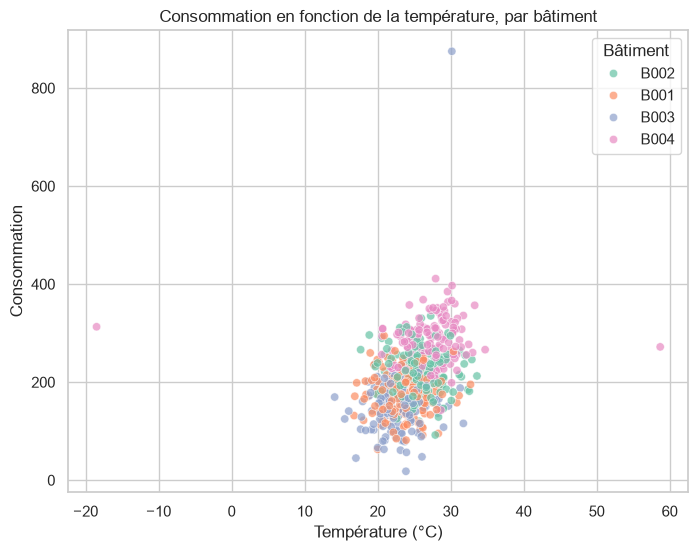

In [37]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x="temperature", y="consommation", hue="batiment", palette="Set2", alpha=0.7)
plt.title("Consommation en fonction de la température, par bâtiment")
plt.xlabel("Température (°C)")
plt.ylabel("Consommation")
plt.legend(title="Bâtiment")
plt.show()

Vue par bâtiment, la tendance générale (consommation qui augmente avec la température) reste visible dans chaque groupe, mais B004 se distingue à nouveau en étirant le nuage de points vers les valeurs de température les plus extrêmes.

3) Modification de la taille des points

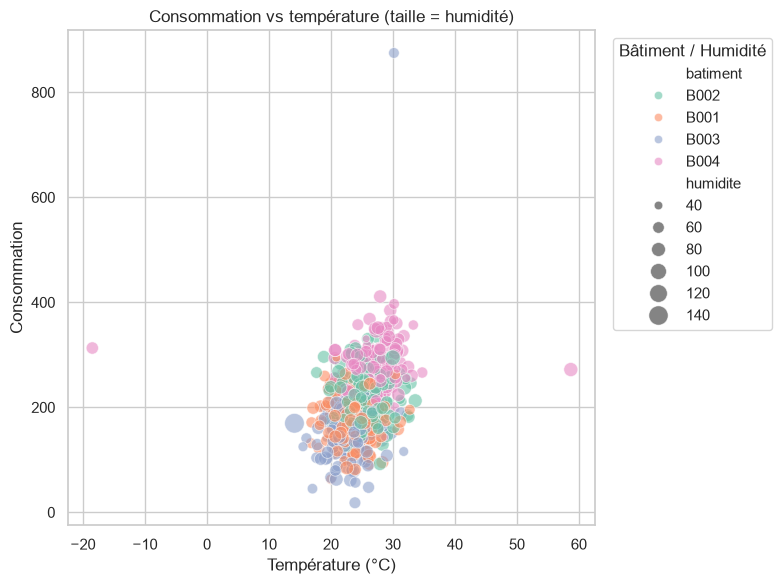

In [38]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x="temperature", y="consommation", hue="batiment",
                 size="humidite", sizes=(20, 200), palette="Set2", alpha=0.6)
plt.title("Consommation vs température (taille = humidité)")
plt.xlabel("Température (°C)")
plt.ylabel("Consommation")
plt.legend(title="Bâtiment / Humidité", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

En plus d'un ajustement direct du paramètre `s` (taille fixe), la taille des points peut être reliée à une troisième variable numérique — ici l'humidité — via le paramètre `size`, ce qui permet de faire apparaître une dimension supplémentaire sur le même graphique.